In [1]:
import os
from pathlib import Path
import numpy as np
import h5py
from src.module.utils import (
    load_npy,
    load_config,
    select_strategy,
    multiprocess_function,
)
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def range_segment(segments):
    if segments.size != 0:
        ranges = np.apply_along_axis(lambda x: np.arange(*x), axis=1, arr=segments)
    else:
        ranges = np.array([], dtype=np.int32)
    return ranges


def assess_segment(ranges, sqi, config):
    if len(ranges) != 0:
        is_bad_quality = np.any(sqi[ranges] > config["sqi"]["threshold"], axis=1)
        samples = ranges[~is_bad_quality]
    else:
        samples = np.array([], dtype=np.int32).reshape(
            -1, config["fs"] * config["input_len"]
        )
    return samples


def run(file_path, config, strategy, label: str):
    cid = str(file_path).split("/")[-2]
    case_path = (
        Path(config["data_path"]).expanduser() / "vitaldb" / "02_04.processed" / cid
    )
    file_name = str(file_path).split("/")[-1].split(".")[0][:-7] + "_segments.npy"
    sig_path = case_path / f"{cid}_100fs_processed.h5"

    with h5py.File(sig_path, "r") as f:
        cid = f.attrs["caseid"]
        sqi = f["signal/sqi"][:].astype(np.float32)

    events = load_npy(file_path)
    segments = strategy.extract_segment(events, config, label)
    ranges = range_segment(segments)
    samples = assess_segment(ranges, sqi, config)

    # save_npy(case_path / file_name, samples)
    return samples

In [3]:
config = load_config("../../config/conf.yaml")
strategy = select_strategy("hypophetversion2")
src_path = Path(config["data_path"]).expanduser() / "vitaldb" / "02_04.processed"

HypophetVersion2 strategy selected.


In [4]:
pos_event_path = sorted(src_path.rglob(f"*{strategy.name}*_pred_pos_events.npy"))
pos_event_path = [x for x in pos_event_path if not x.name.startswith("._")]
neg_event_path = sorted(src_path.rglob(f"*{strategy.name}*_neg_events.npy"))
neg_event_path = [x for x in neg_event_path if not x.name.startswith("._")]

In [5]:
for idx in tqdm(range(len(neg_event_path)), ncols=75):
    cid = neg_event_path[idx].parent.name
    case_path = src_path / cid
    file_name = (
        str(neg_event_path[idx]).split("/")[-1].split(".")[0][:-7] + "_segments.npy"
    )
    sig_path = case_path / f"{cid}_100fs_processed.h5"

    with h5py.File(sig_path, "r") as f:
        cid = f.attrs["caseid"]
        sig = f["signal/abp"][:]
        sqi = f["signal/sqi"][:].astype(np.float32)

    sqi = np.where(np.isnan(sqi), 1.0, sqi)
    events = load_npy(neg_event_path[idx])
    segments = strategy.extract_segment(events, config, "pos")
    ranges = range_segment(segments)
    samples = assess_segment(ranges, sqi, config)

    if len(samples) == 0:
        continue

    if np.mean(sig[samples], axis=1).min() < 10:
        print(idx)

100%|██████████████████████████████████| 3507/3507 [01:31<00:00, 38.26it/s]


In [6]:
# 377, 697, 1307, 1495, 1782, 2184, 2419, 2574, 2640
idx = 377
cid = neg_event_path[idx].parent.name
case_path = src_path / cid
file_name = str(neg_event_path[idx]).split("/")[-1].split(".")[0][:-7] + "_segments.npy"
sig_path = case_path / f"{cid}_100fs_processed.h5"

In [81]:
with h5py.File(sig_path, "r") as f:
    cid = f.attrs["caseid"]
    sig = f["signal/abp"][:]
    sqi = f["signal/sqi"][:].astype(np.float32)

In [82]:
sqi = np.where(np.isnan(sqi), 1.0, sqi)

In [83]:
events = load_npy(neg_event_path[idx])
print(events.shape)

(1, 2)


In [85]:
segments = strategy.extract_segment(events, config, "neg")
print(segments.shape)
ranges = range_segment(segments)
print(ranges.shape)
samples = assess_segment(ranges, sqi, config)
print(samples.shape)

(44, 2)
(44, 3000)
(0, 3000)


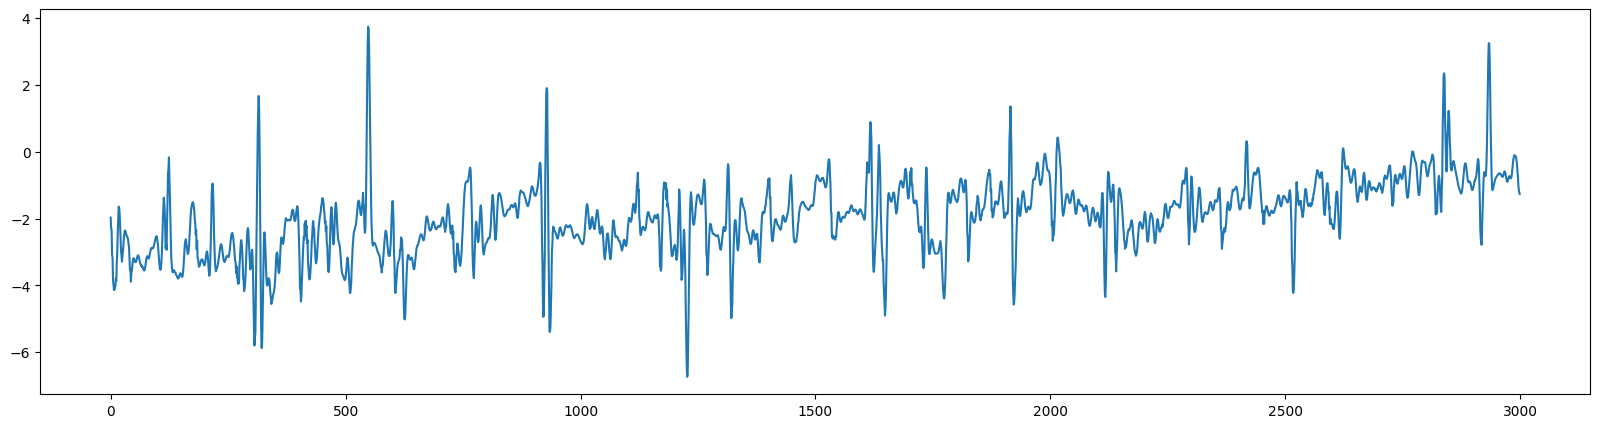

In [23]:
plt.figure(figsize=(20, 5))
plt.plot(sig[samples[-10]])
plt.show()